# K-Means Clustering: Theory & Algorithm

K-means is one of the most widely used unsupervised learning algorithms for partitioning data into K distinct clusters. Here's a comprehensive overview:

## Core Concept

K-means divides a dataset into K clusters by minimizing the **within-cluster sum of squared distances (inertia)**. **Each cluster is represented by its centroid—the mean of all points assigned to that cluster**.

**Objective:** Minimize the inertia function:
$$J = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Where:
- $C_i$ = set of points in cluster $i$
- $\mu_i$ = centroid of cluster $i$
- $K$ = number of clusters

## The Algorithm (Lloyd's Algorithm)

K-means follows an iterative two-step process:

### 1. **Initialization**
- Randomly select K initial centroids from the data (or use K-means++ for smarter initialization)
- K-means++ reduces the risk of poor local optima by spreading initial centroids

### 2. **Assignment Step**
- Assign each data point to the nearest centroid using Euclidean distance
- Forms K clusters based on closest centroid

### 3. **Update Step**
- Recalculate each centroid as the mean of all points in its cluster
- $\mu_i^{new} = \frac{1}{|C_i|} \sum_{x \in C_i} x$

### 4. **Convergence Check**
- Repeat steps 2–3 until:
  - Centroids stop moving (or move below a threshold)
  - Maximum iterations reached
  - Inertia change is negligible

## Key Properties

| Property | Details |
|----------|---------|
| **Complexity** | O(n·K·i·d) where n=samples, K=clusters, i=iterations, d=dimensions |
| **Convergence** | Always converges, but may reach local optima (not global) |
| **Scalability** | Efficient on large datasets; linear in number of samples |
| **Data Type** | Works with numerical, continuous data |
| **Sensitivity** | Sensitive to initialization and outliers; assumes spherical clusters |

## Choosing K: Elbow Method & Silhouette Score

**Elbow Method:**
- Compute inertia for K = 1, 2, 3, ..., n
- Plot inertia vs. K
- Look for the "elbow"—where inertia reduction flattens
- Choose K at the elbow

**Silhouette Score:**
- Measures how similar a point is to its own cluster vs. other clusters
- Range: [-1, 1]; higher is better
- $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$
  - $a(i)$ = avg distance to points in same cluster
  - $b(i)$ = avg distance to points in nearest cluster

## Advantages & Limitations

**Strengths:**
- Simple, fast, and interpretable
- Scales well to large datasets
- Works well for spherical, similarly-sized clusters

**Weaknesses:**
- Sensitive to initialization (use K-means++)
- Assumes clusters are convex and similarly sized
- Struggles with clusters of different densities or shapes
- Outliers can distort centroids
- Requires specifying K in advance
- Local optima problem

## Variants & Improvements

- **K-means++**: Smarter initialization for better convergence
- **Mini-batch K-means**: Faster, uses random subsets for large data
- **K-medoids**: Uses actual data points as centroids (more robust to outliers)
- **Hierarchical K-means**: Combines hierarchical clustering with K-means

## Practical Example (Python)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
iris = datasets.load_iris()
X_data, y = iris.data, iris.target
X_norm = StandardScaler().fit_transform(X_data)

In [3]:
# Generate or load data
X = X_norm[:, [0,2]]  # (n_samples, n_features)

# Elbow method to find optimal K
inertias = []
silhouette_scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Fit K-means with optimal K
optimal_k = 3  # from elbow plot
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

/var/mobile/Containers/Data/Application/F9B90C93-2EC0-4925-AEA2-79B1551BA58B/Documents/site-packages/threadpoolctl.py:990: RuntimeWarning: Could not find dl_iterate_phdr in the C standard library.
  warnings.warn(


#### Silhoustte Score:

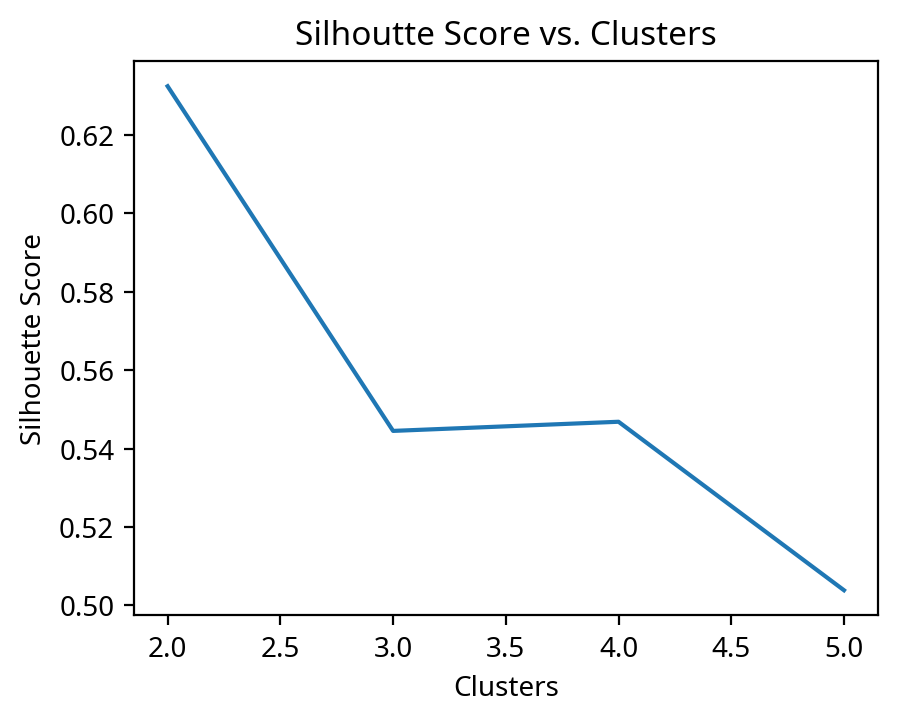

In [4]:
plt.plot(list(K_range), silhouette_scores)
plt.title('Silhoutte Score vs. Clusters')
plt.xlabel('Clusters')
plt.ylabel('Silhouette Score')
plt.show()

#### k-means prediction

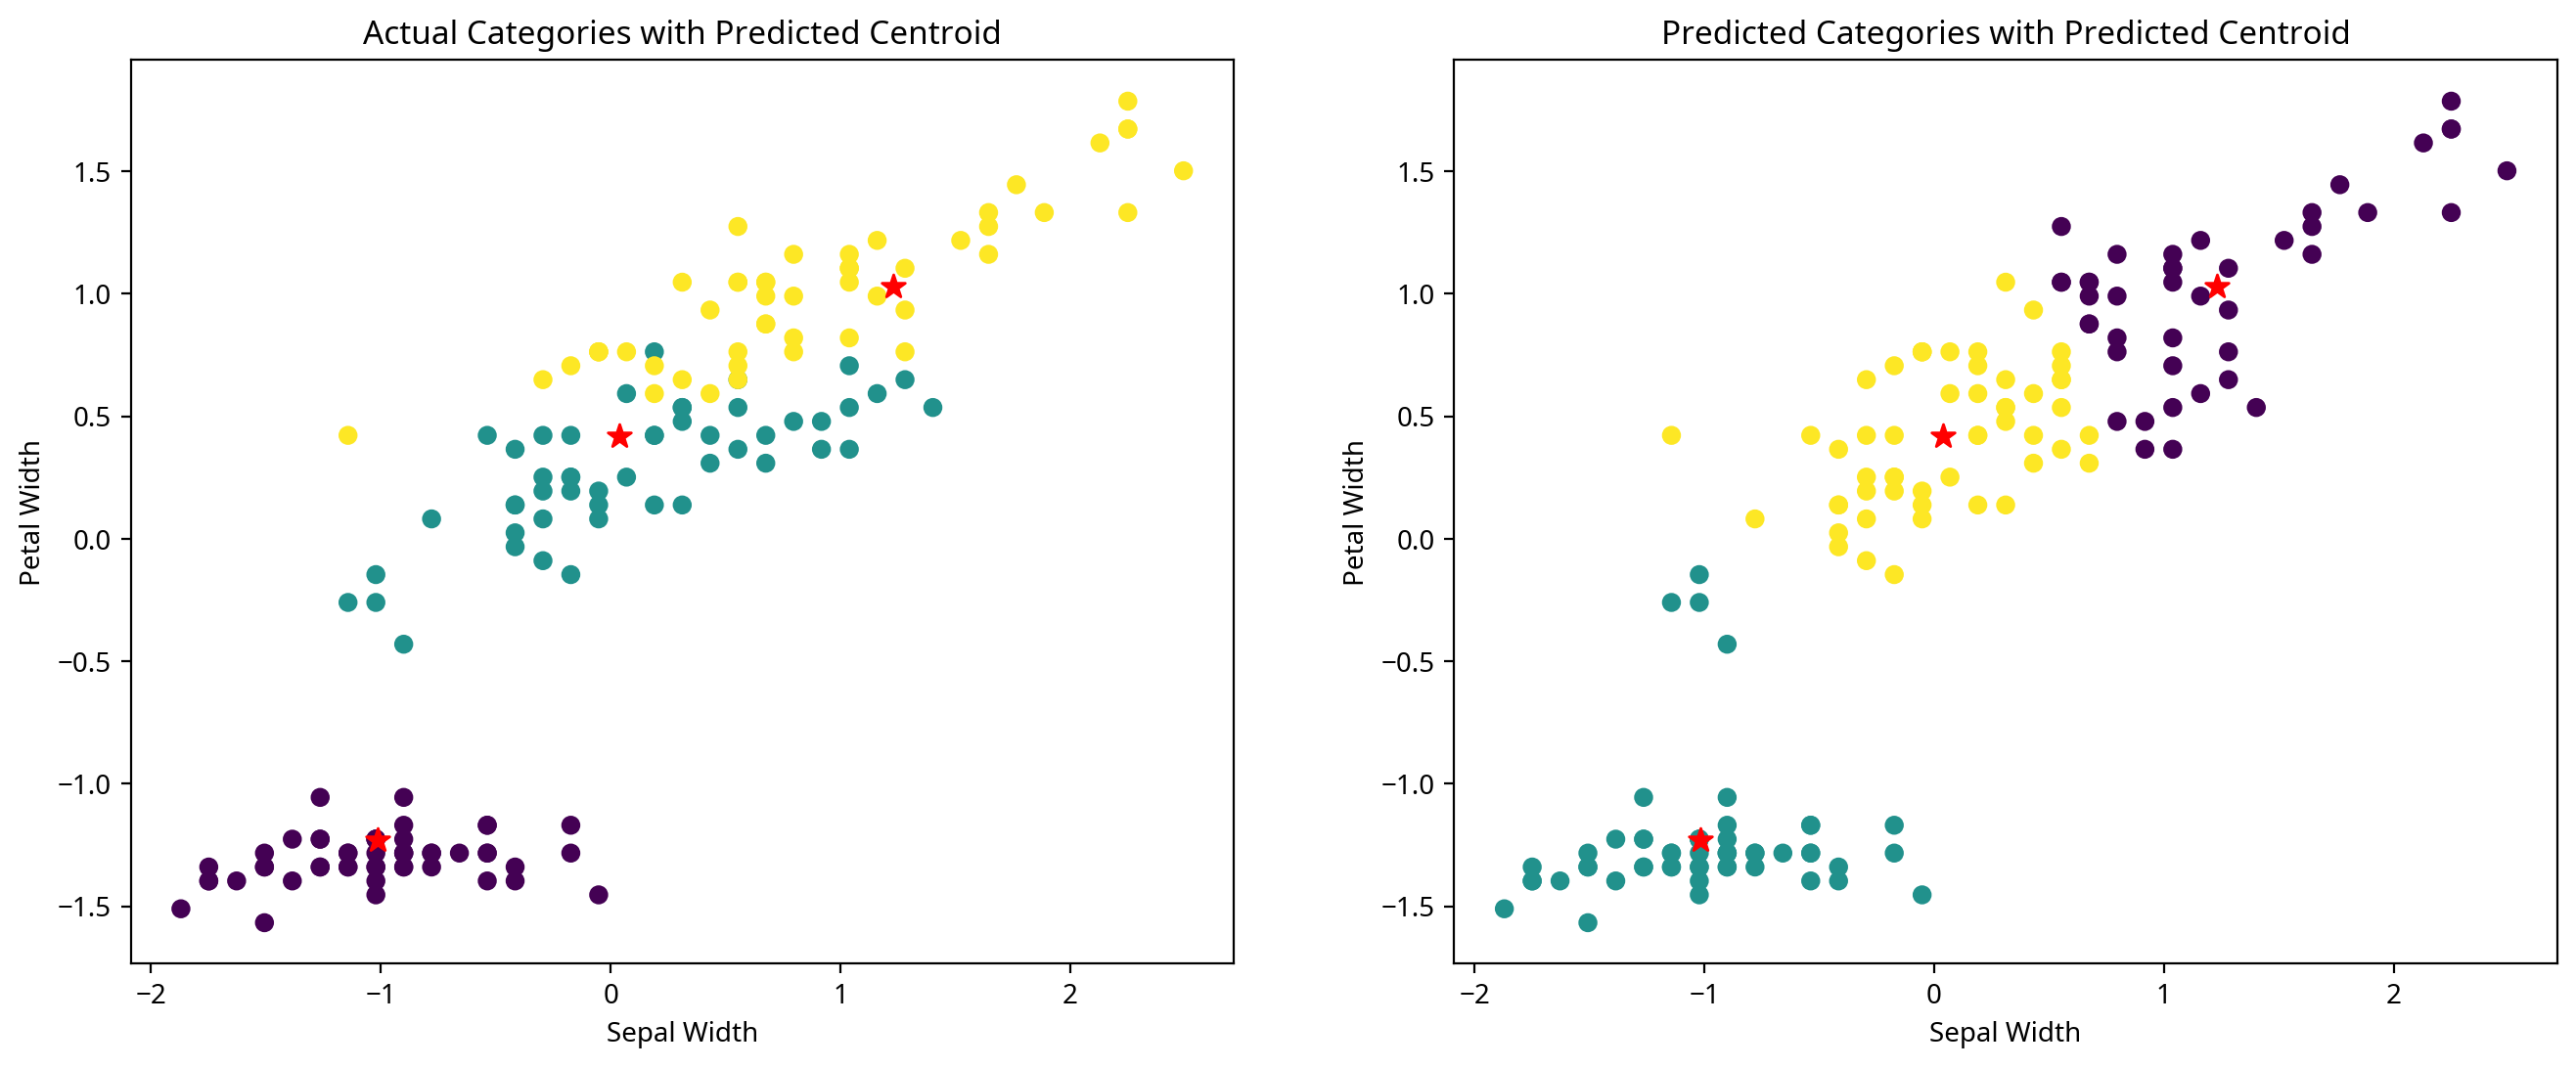

In [5]:
fig, axis = plt.subplots(1,2, figsize=(16,6))
axis[0].scatter(X[:, 0], X[:, 1], c=y)
axis[0].scatter(centroids[:,0], centroids[:,1], marker='*', s=80, color='r')
axis[0].set_xlabel('Sepal Width')
axis[0].set_ylabel('Petal Width')
axis[0].set_title('Actual Categories with Predicted Centroid')

axis[1].scatter(X[:, 0], X[:, 1], c=labels)
axis[1].scatter(centroids[:,0], centroids[:,1], marker='*', s=80, color='r')
axis[1].set_xlabel('Sepal Width')
axis[1].set_ylabel('Petal Width')
axis[1].set_title('Predicted Categories with Predicted Centroid')
plt.show()